# Hotel Booking Cancellation — Training and Evaluation

ML Assignment 2 — six classification models trained on the [Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand) dataset to predict whether a booking will be cancelled (`is_canceled`).

**Layout of this notebook**

1. Raw data, leakage and duplicate audit
2. Exploratory analysis
3. Cleaning, train/test split and test-data export
4. Model training
5. Results and confusion matrices

Cleaning, the feature transformer and the metric definitions are imported from `model/preprocessing.py` and `model/evaluation.py` so that the Streamlit app scores uploaded data exactly the way it is scored here. Only the training itself lives in this notebook.

Running this notebook top to bottom regenerates `test_data.csv`, `model/metrics.csv` and everything in `model/saved_models/`.

In [1]:
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

ROOT = Path.cwd().parent if Path.cwd().name == "model" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from model.config import (
    CATEGORICAL_FEATURES,
    FEATURES,
    KNN_SUBSAMPLE_SIZE,
    METRICS_FILE,
    MODEL_NAMES,
    NUMERIC_FEATURES,
    RANDOM_STATE,
    RAW_DATA,
    SAVED_MODELS_DIR,
    TARGET,
    TEST_DATA,
    TEST_SIZE,
)
from model.evaluation import confusion, evaluate, metrics_table
from model.preprocessing import build_preprocessor, load_and_clean

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("python      ", sys.version.split()[0])
print("scikit-learn", sklearn.__version__)
print("project root", ROOT)

python       3.11.13
scikit-learn 1.9.0
project root /Users/amruth.s/MTech/Semester-2/ML/Assignment_2


## 1. Raw data, leakage and duplicate audit

Before any modelling, three things need checking, because each one would otherwise silently distort every metric in the comparison table.

**Target leakage.** `reservation_status` records the outcome of the booking, so it maps one-to-one onto the target and would let any model score near-perfectly without learning anything. `reservation_status_date` is only known once the booking has resolved, and `assigned_room_type` is settled at check-in — after cancellation is already known. All three are dropped.

**High-cardinality identifiers.** `agent` and `company` have hundreds of levels and `company` is almost entirely missing, but they carry real signal: cancellation rates across the ten busiest agents run from 0.07 to 0.73. They are known at booking time, so they are legitimate predictors rather than leakage. Both are kept as categorical features with their missing values encoded as an explicit `None` level, and the rare-category threshold below keeps the encoded width in check.

**Duplicates.** A large share of rows are exact repeats. Left in place, a random train/test split puts identical rows on both sides, so the nearest-neighbour and tree models would be scored partly on rows they had memorised.

In [2]:
raw = pd.read_csv(RAW_DATA)

print(f"shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns\n")

print("class balance:")
print(raw[TARGET].value_counts(normalize=True).rename({0: "not cancelled", 1: "cancelled"}).round(4), "\n")

print("missing values:")
print(raw.isnull().sum().loc[lambda s: s > 0].to_string(), "\n")

print(f"exact duplicate rows: {raw.duplicated().sum():,} ({raw.duplicated().mean():.1%})\n")

print("high-cardinality columns:")
for column in ["country", "agent", "company"]:
    print(f"  {column:<8} {raw[column].nunique():>4} levels   {raw[column].isnull().mean():>6.1%} missing")

print("\nleakage check - reservation_status against the target:")
print(pd.crosstab(raw["reservation_status"], raw[TARGET]))

shape: 119,390 rows x 32 columns

class balance:
is_canceled
not cancelled    0.6296
cancelled        0.3704
Name: proportion, dtype: float64 

missing values:
children         4
country        488
agent        16340
company     112593 

exact duplicate rows: 31,994 (26.8%)

high-cardinality columns:
  country   177 levels     0.4% missing
  agent     333 levels    13.7% missing
  company   352 levels    94.3% missing

leakage check - reservation_status against the target:
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207


## 2. Exploratory analysis

Four views that motivate the feature choices: the class balance, and how the cancellation rate varies with hotel type, deposit policy and lead time.

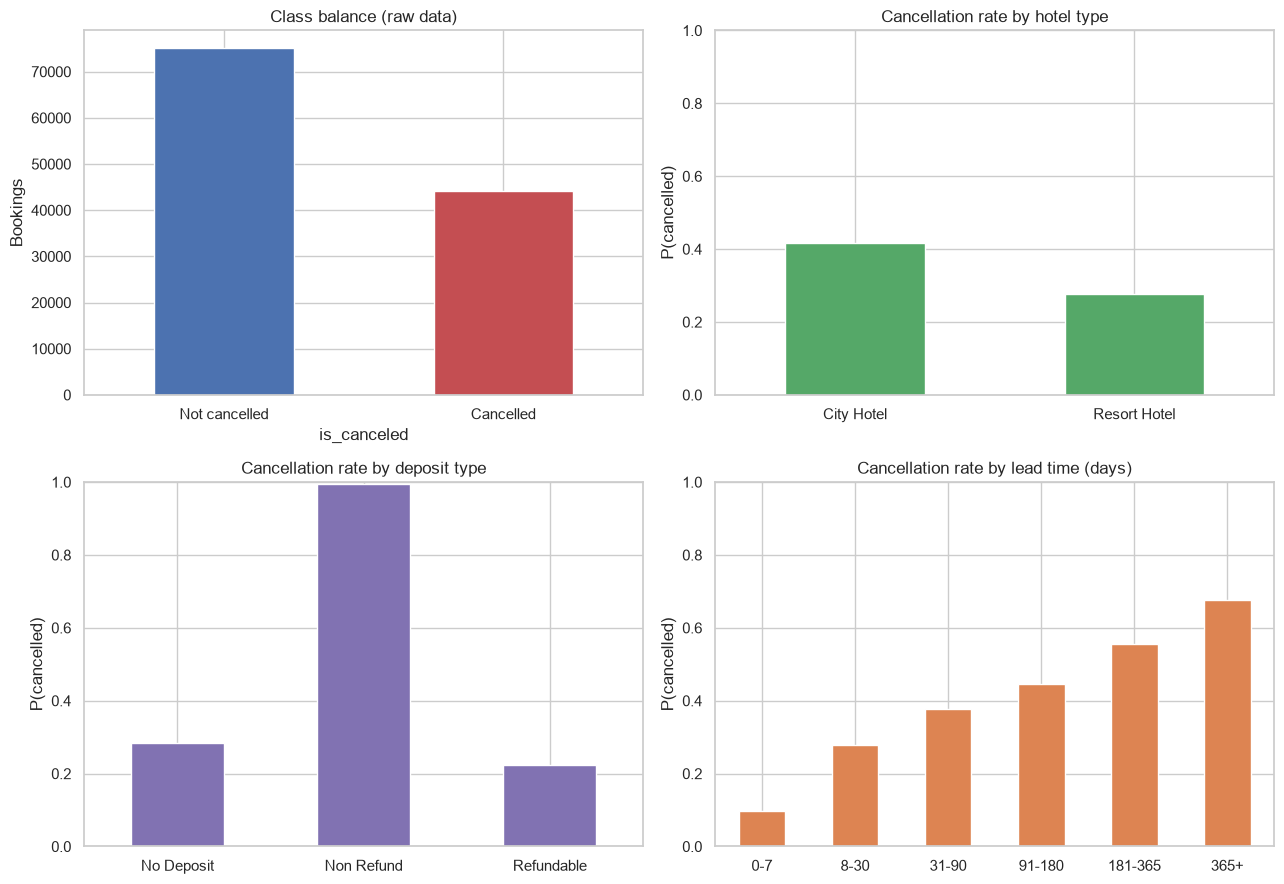

Non-refundable deposits cancel far more often than refundable ones, and
cancellation risk rises steadily with how far ahead the booking was made.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

(
    raw[TARGET]
    .value_counts()
    .rename({0: "Not cancelled", 1: "Cancelled"})
    .plot(kind="bar", ax=axes[0, 0], color=["#4c72b0", "#c44e52"], rot=0)
)
axes[0, 0].set_title("Class balance (raw data)")
axes[0, 0].set_ylabel("Bookings")

raw.groupby("hotel")[TARGET].mean().plot(kind="bar", ax=axes[0, 1], color="#55a868", rot=0)
axes[0, 1].set_title("Cancellation rate by hotel type")

raw.groupby("deposit_type")[TARGET].mean().plot(kind="bar", ax=axes[1, 0], color="#8172b2", rot=0)
axes[1, 0].set_title("Cancellation rate by deposit type")

lead_bins = pd.cut(raw["lead_time"], [-1, 7, 30, 90, 180, 365, 800],
                   labels=["0-7", "8-30", "31-90", "91-180", "181-365", "365+"])
raw.groupby(lead_bins, observed=True)[TARGET].mean().plot(kind="bar", ax=axes[1, 1], color="#dd8452", rot=0)
axes[1, 1].set_title("Cancellation rate by lead time (days)")

for ax in axes.flat[1:]:
    ax.set_ylim(0, 1)
    ax.set_ylabel("P(cancelled)")
    ax.set_xlabel("")

plt.tight_layout()
plt.show()

print("Non-refundable deposits cancel far more often than refundable ones, and")
print("cancellation risk rises steadily with how far ahead the booking was made.")

## 3. Cleaning, split and test-data export

`load_and_clean` drops the leakage columns, fills the few missing `children` and `country` values, normalises `agent` and `company` into labelled categories, removes bookings with zero guests, clips the `adr` outliers (the raw column runs from -6.38 to 5400), and only then de-duplicates.

Seven features are engineered on top of the raw columns: `total_nights`, `total_guests`, `is_family`, `has_agent`, `has_company`, `adr_per_guest`, and `prev_cancel_ratio` (the share of a guest's earlier bookings that were cancelled). An eighth, `arrival_weekday`, is reconstructed from the split year/month/day columns — arrival day of week matters, with cancellation rates running from 0.32 on Sundays to 0.41 on Thursdays.

De-duplicating **last** matters: collapsing `agent` and `company` into flags merges rows that previously differed only by agent ID, so removing duplicates any earlier lets them reappear in the final feature set.

The duplicate feature rows that survive are the ones whose labels disagree — genuinely identical bookings with different outcomes. Those are kept, since they represent irreducible error rather than redundancy, and they are the reason no model here should be expected to approach 100%.

The split is stratified 80/20. The test half is written to `test_data.csv` with labels attached, which is what the Streamlit app loads.

In [4]:
df = load_and_clean(RAW_DATA)

print(f"raw rows           : {len(raw):,}")
print(f"cleaned rows       : {len(df):,}   (removed {len(raw) - len(df):,})")
print(f"features           : {len(FEATURES)}   ({len(NUMERIC_FEATURES)} numeric + {len(CATEGORICAL_FEATURES)} categorical)")
print(f"missing values     : {int(df.isnull().sum().sum())}")
print(f"exact duplicates   : {df.duplicated().sum()}")
print(f"conflicting labels : {df[FEATURES].duplicated().sum()} identical bookings with opposite outcomes")

balance = pd.DataFrame({
    "raw": raw[TARGET].value_counts(normalize=True),
    "cleaned": df[TARGET].value_counts(normalize=True),
}).rename({0: "not cancelled", 1: "cancelled"})
print("\nclass balance shifts once duplicates are removed:")
print(balance.round(4))

X, y = df[FEATURES], df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

pd.concat([X_test, y_test], axis=1).to_csv(TEST_DATA, index=False)

train_rows = set(map(tuple, X_train.itertuples(index=False)))
overlap = sum(1 for row in X_test.itertuples(index=False) if tuple(row) in train_rows)

print(f"\ntrain {X_train.shape}   test {X_test.shape}")
print(f"wrote {TEST_DATA.name} ({TEST_DATA.stat().st_size / 1e6:.1f} MB)")
print(f"test rows also present in train: {overlap} ({overlap / len(X_test):.2%})")

raw rows           : 119,390
cleaned rows       : 85,984   (removed 33,406)
features           : 36   (24 numeric + 12 categorical)
missing values     : 0
exact duplicates   : 0
conflicting labels : 281 identical bookings with opposite outcomes

class balance shifts once duplicates are removed:
                  raw  cleaned
is_canceled                   
not cancelled  0.6296   0.7242
cancelled      0.3704   0.2758



train (68787, 36)   test (17197, 36)
wrote test_data.csv (2.5 MB)
test rows also present in train: 102 (0.59%)


## 4. Model training

Every model is wrapped in the same `Pipeline`, so the transformer is fitted on the training split alone and the imputation medians, scaler statistics and category vocabularies never see the test data.

The transformer imputes and standardises the numeric columns, and one-hot encodes the categorical ones with `min_frequency=50` so that the long tail of rare countries collapses into a single bucket instead of adding 177 columns. That threshold is learned from the training split only, and unseen categories at inference map to the same bucket, so the app cannot crash on a country it has never encountered.

All six models are compared under one identical protocol: the same features, the same transformer and the same default 0.5 decision threshold. That keeps any difference in the table attributable to the algorithm itself rather than to per-model tinkering.

Two models need deliberate limits to stay deployable, since Streamlit Community Cloud is memory-constrained and GitHub rejects files over 100 MB. kNN stores its entire training set inside the pickle, so it is fitted on a stratified 15,000-row subsample. The random forest is depth-capped for the same reason.

A sixth model, gradient boosting, is included beyond the five the assignment lists explicitly.

In [5]:
estimators = {
    "logistic_regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(
        max_depth=16, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
    "knn": KNeighborsClassifier(n_neighbors=25, weights="distance", n_jobs=-1),
    "naive_bayes": GaussianNB(),
    "random_forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE
    ),
    "gradient_boosting": HistGradientBoostingClassifier(
        max_iter=300, learning_rate=0.1, random_state=RANDOM_STATE
    ),
}

results = {}
fitted = {}

for key, estimator in estimators.items():
    name = MODEL_NAMES[key]

    if key == "knn" and len(X_train) > KNN_SUBSAMPLE_SIZE:
        X_fit, _, y_fit, _ = train_test_split(
            X_train, y_train, train_size=KNN_SUBSAMPLE_SIZE,
            stratify=y_train, random_state=RANDOM_STATE,
        )
    else:
        X_fit, y_fit = X_train, y_train

    pipeline = Pipeline([("preprocess", build_preprocessor()), ("model", estimator)])

    started = time.perf_counter()
    pipeline.fit(X_fit, y_fit)
    fit_seconds = time.perf_counter() - started

    results[name] = evaluate(pipeline, X_test, y_test)
    fitted[name] = pipeline

    path = SAVED_MODELS_DIR / f"{key}.joblib"
    joblib.dump(pipeline, path, compress=3)

    print(f"{name:<28} fit {fit_seconds:>6.1f}s on {len(X_fit):>6,} rows"
          f"   ->  {path.name:<26} {path.stat().st_size / 1e6:>5.1f} MB")

print(f"\nencoded width: {pipeline.named_steps['preprocess'].transform(X_test.head(1)).shape[1]} columns")

Logistic Regression          fit    1.2s on 68,787 rows   ->  logistic_regression.joblib   0.0 MB


Decision Tree                fit    1.0s on 68,787 rows   ->  decision_tree.joblib         0.1 MB


kNN                          fit    0.1s on 15,000 rows   ->  knn.joblib                   1.3 MB


Naive Bayes (Gaussian)       fit    0.6s on 68,787 rows   ->  naive_bayes.joblib           0.0 MB


Random Forest (Ensemble)     fit    2.6s on 68,787 rows   ->  random_forest.joblib        18.4 MB


Gradient Boosting (Ensemble) fit    4.8s on 68,787 rows   ->  gradient_boosting.joblib     0.4 MB

encoded width: 219 columns


## 5. Results

All six models are scored on the same held-out test split. Because de-duplication left the classes at roughly 72/28, accuracy alone is misleading — always predicting "not cancelled" already scores about 0.72. The winner is therefore chosen on Matthews correlation coefficient, which accounts for all four cells of the confusion matrix, with AUC as the supporting measure.

The table is written to `model/metrics.csv`, which is the same file the README comparison table and the Streamlit app both report.

               ML Model Name  Accuracy    AUC  Precision  Recall     F1    MCC
         Logistic Regression    0.8012 0.8587     0.6830  0.5210 0.5911 0.4703
               Decision Tree    0.8269 0.8798     0.7139  0.6218 0.6646 0.5511
                         kNN    0.7906 0.8177     0.6774  0.4596 0.5477 0.4312
      Naive Bayes (Gaussian)    0.5198 0.7105     0.3544  0.9022 0.5089 0.2700
    Random Forest (Ensemble)    0.8346 0.9020     0.8017  0.5317 0.6394 0.5567
Gradient Boosting (Ensemble)    0.8478 0.9157     0.7484  0.6749 0.7098 0.6084

majority-class baseline accuracy: 0.7242
best MCC: Gradient Boosting (Ensemble)
wrote model/metrics.csv


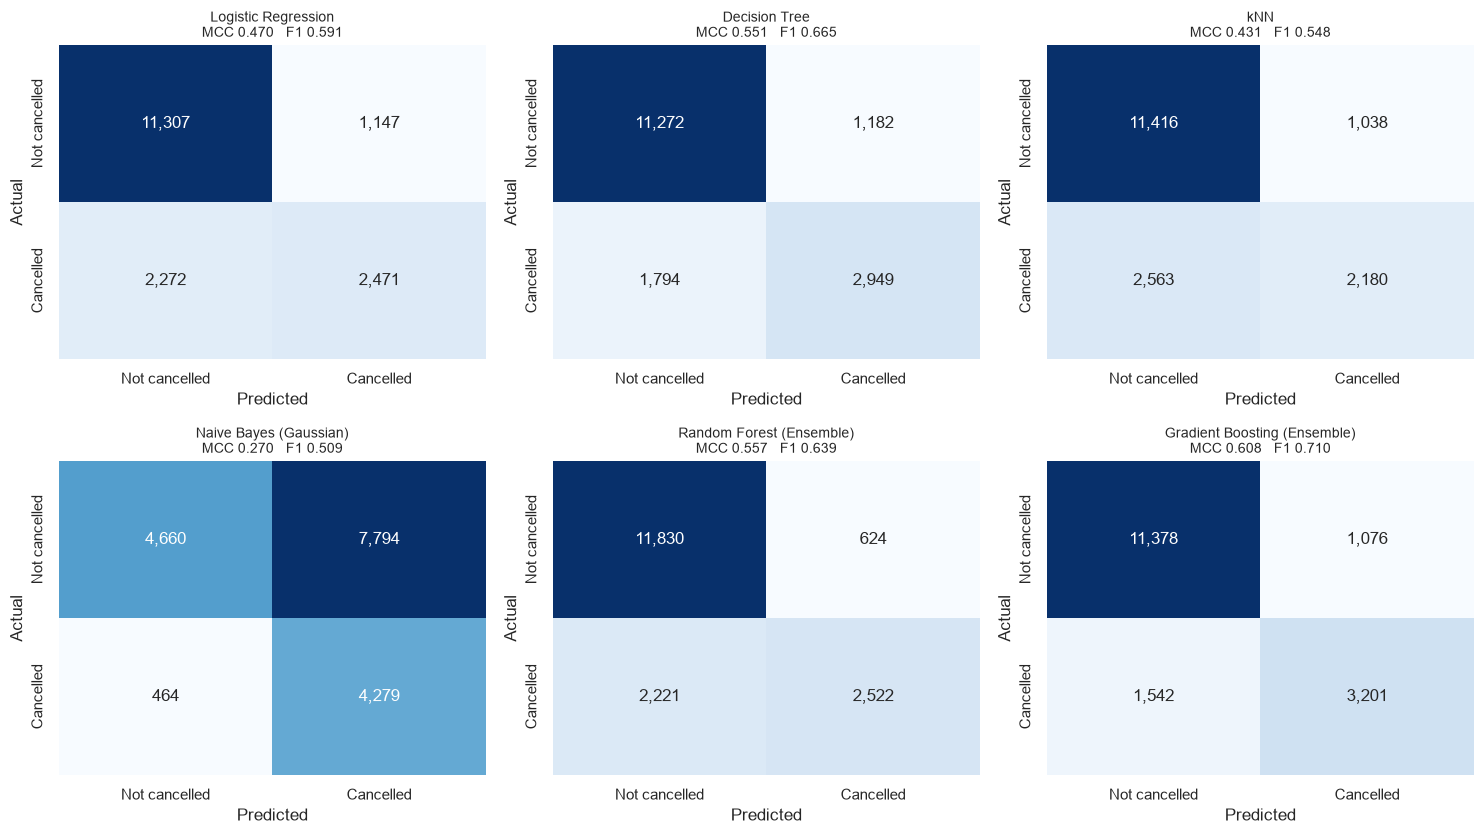

In [6]:
table = metrics_table(results)
table.to_csv(METRICS_FILE, index=False)

baseline = max(y_test.mean(), 1 - y_test.mean())
winner = table.loc[table["MCC"].idxmax(), "ML Model Name"]

print(table.round(4).to_string(index=False))
print(f"\nmajority-class baseline accuracy: {baseline:.4f}")
print(f"best MCC: {winner}")
print(f"wrote {METRICS_FILE.relative_to(ROOT)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
labels = ["Not cancelled", "Cancelled"]

for ax, (name, pipeline) in zip(axes.flat, fitted.items()):
    sns.heatmap(
        confusion(pipeline, X_test, y_test),
        annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=labels, yticklabels=labels,
    )
    ax.set_title(f"{name}\nMCC {results[name]['MCC']:.3f}   F1 {results[name]['F1']:.3f}", fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()